<a href="https://colab.research.google.com/github/thanannthy88/Python_BarChart/blob/main/Predictive_GroupP15_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Introduction
## Breast Cancer Prediction
This project analyzes breast cancer data to build classification models that predict whether a tumor is benign or malignant based on measured features.
Note: the dataset below is provided from classroom materials.

In [ ]:
#from preamble import *

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# to make this notebook's output identical/stable across runs
np.random.seed(7)

# set up numpy to display precision upto 3 decimal places and suppresses the use of scientific notation for small numbers
#np.set_printoptions(precision=3, suppress=True)
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})
pd.set_option('display.max_columns', None) # show all columns in a Pandas DataFrame
pd.set_option('display.max_rows', None)
#pd.set_option('precision', 3)

# To plot georgeous figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
mpl.rcParams['savefig.dpi'] = 80
mpl.rcParams['figure.dpi'] = 80
plt.rcParams['image.cmap'] = "gray"

# Where to save the data and figures
PROJECT_ROOT_DIR = "."
IMAGES_DIR = "images"
DATA_DIR = "data"
SUB_DIR = "model-eval"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, IMAGES_DIR, SUB_DIR)
DATA_PATH = os.path.join(PROJECT_ROOT_DIR, DATA_DIR, SUB_DIR)
os.makedirs(IMAGES_PATH, exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)

# Function for saving figures
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")
#warnings.filterwarnings(action='ignore', category=DeprecationWarning, module='sklearn')
#warnings.filterwarnings(action='ignore', category=FutureWarning, module='sklearn')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/Predictive Analysis/Project/Breast_Cancer_Research/Code/Data

/content/drive/MyDrive/Colab Notebooks/Predictive Analysis/Project/Breast_Cancer_Research/Code/Data


# 2. Data PreProcessing

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Predictive Analysis/Project/Breast_Cancer_Research/Code/Data/breast_cancer.csv'
full_df = pd.read_csv(path)
full_df.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant


In [ ]:
 # Display the first 10 row
full_df.head(10)

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant
5,5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,0.3345,0.8902,2.217,27.19,0.007510,0.03345,0.03672,0.01137,0.02165,0.005082,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,Malignant
6,6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,Malignant
7,7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,0.5835,1.3770,3.856,50.96,0.008805,0.03029,0.02488,0.01448,0.01486,0.005412,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,Malignant
8,8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,0.3063,1.0020,2.406,24.32,0.005731,0.03502,0.03553,0.01226,0.02143,0.003749,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,Malignant
9,9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,0.2976,1.5990,2.039,23.94,0.007149,0.07217,0.07743,0.01432,0.01789,0.010080,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,Malignant


In [ ]:
 # Display the last 5 rows
full_df.tail()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,Malignant
565,565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,Malignant
566,566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,Malignant
567,567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,Malignant
568,568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,Benign


In [ ]:
# Display the 201st row for inspection
full_df.iloc[200]

,200
Unnamed: 0,200
mean radius,12.23
mean texture,19.56
mean perimeter,78.54
mean area,461.0
mean smoothness,0.09586
mean compactness,0.08087
mean concavity,0.04187
mean concave points,0.04107
mean symmetry,0.1979


In [ ]:
# Count missing values in each column
full_df.isnull().sum()

,0
Unnamed: 0,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0


In [ ]:
# === Identify Columns with Missing Values ===
missing_cols = full_df.columns[full_df.isnull().any()].tolist()
print(missing_cols)

['texture error', 'worst perimeter']


In [ ]:
# === Show Count of Missing Values in Those Columns ===
print(full_df[missing_cols].isnull().sum())


texture error      2
worst perimeter    3
dtype: int64


In [ ]:
# === Drop Rows with Missing Values ===
full_df = full_df.dropna()

In [ ]:
# Drop unnamed columns (likely index column)
full_df = full_df.loc[:, ~full_df.columns.str.contains('^Unnamed')]

# Check the first few rows to confirm
full_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant


In [ ]:
# === Confirm Missing Values Are Handled ===
full_df.isnull().sum()
if full_df.isnull().sum().sum() == 0:
    print("No missing values remain in the dataset.")
else:
    print("Caution! There are still missing values present.")

No missing values remain in the dataset.


In [ ]:
full_df.shape

(564, 31)

In [ ]:
full_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant


# 3. Descriptive Analytics

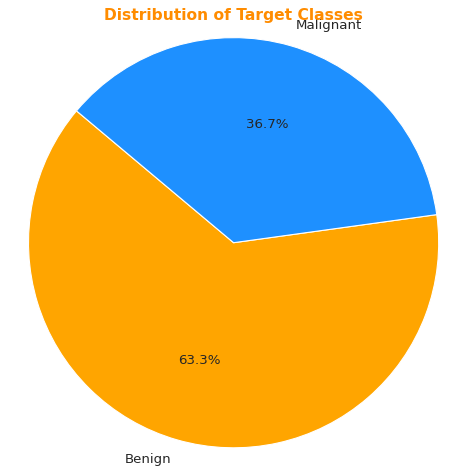

In [ ]:
import matplotlib.pyplot as plt

# Count the occurrences of each class
target_counts = full_df['target'].value_counts()

# Define a mix of flashy orange and vibrant blue shades
colors = ['#FFA500', '#1E90FF', '#FF8C00', '#00BFFF', '#FF4500', '#87CEFA']  # Add/reduce based on number of classes

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(target_counts,
        labels=target_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors[:len(target_counts)])  # Ensure matching count

plt.title('Distribution of Target Classes', fontsize=14, color='darkorange', weight='bold')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.
plt.tight_layout()
plt.show()


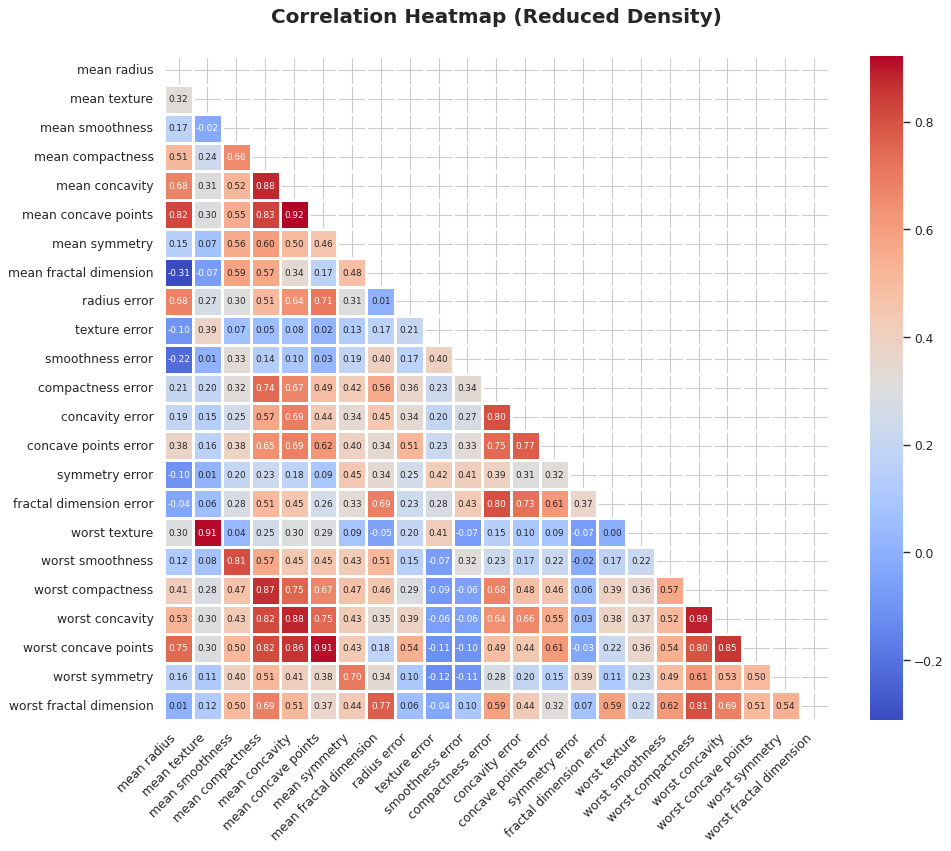

In [ ]:
# Make a copy of the original DataFrame
df_for_heatmap = full_df.copy()

# Calculate correlation matrix (numeric columns only)
corr_matrix = df_for_heatmap.corr(numeric_only=True)

# Set threshold
threshold = 0.95
high_corr = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            high_corr.add(colname)

# Drop highly correlated columns just in the heatmap copy
df_for_heatmap = df_for_heatmap.drop(columns=high_corr)

# Calculate cleaned correlation matrix
corr_matrix_cleaned = df_for_heatmap.corr(numeric_only=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix_cleaned, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(14, 14))  # Bigger figure
sns.set(style="whitegrid")
sns.heatmap(corr_matrix_cleaned,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=1.0,
            linecolor='white',
            cbar_kws={"shrink": 0.7},
            annot_kws={'size': 8})  # Smaller annotation text

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.title('Correlation Heatmap (Reduced Density)', fontsize=18, weight='bold', pad=30)
plt.tight_layout(pad=5)
plt.show()


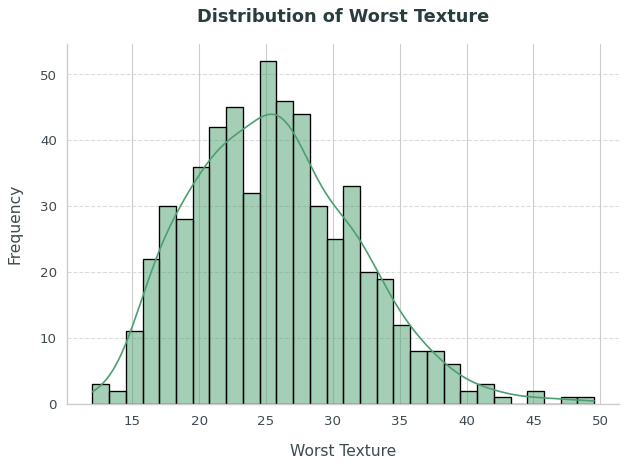

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style to a more aesthetic one
sns.set(style="whitegrid", palette="muted")

# Create the plot with a more elegant and professional look
plt.figure(figsize=(8, 6))

# Plot histogram with KDE
sns.histplot(
    full_df['worst texture'],
    bins=30,
    kde=True,
    color='#4C9F70',   # Soft greenish color for a calm look
    edgecolor='black',
    linewidth=1.2
)

# Title and axis labels with a modern font
plt.title('Distribution of Worst Texture', fontsize=16, weight='bold', color='#2A3D3D', pad=20)
plt.xlabel('Worst Texture', fontsize=14, color='#3E4A4F', labelpad=15)
plt.ylabel('Frequency', fontsize=14, color='#3E4A4F', labelpad=15)

# Customize gridlines for a smooth background
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tidy up the plot with soft aesthetics
sns.despine()  # Remove top and right spines
plt.xticks(fontsize=12, color='#3E4A4F')
plt.yticks(fontsize=12, color='#3E4A4F')

# Show the plot with tight layout
plt.tight_layout()
plt.show()


<ipython-input-65-c18a24902e28>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='worst radius', data=full_df, palette='coolwarm')


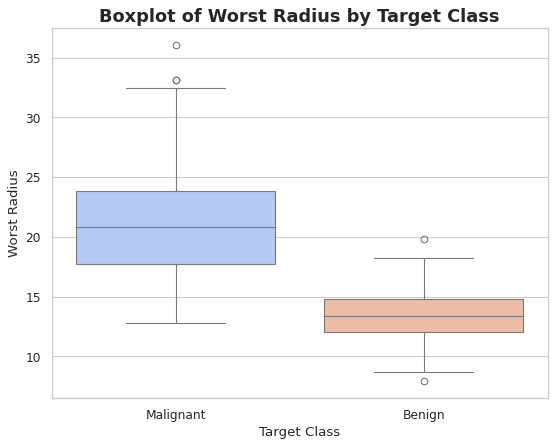

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='worst radius', data=full_df, palette='coolwarm')
plt.title('Boxplot of Worst Radius by Target Class', fontsize=16, weight='bold')
plt.xlabel('Target Class', fontsize=12)
plt.ylabel('Worst Radius', fontsize=12)
plt.show()


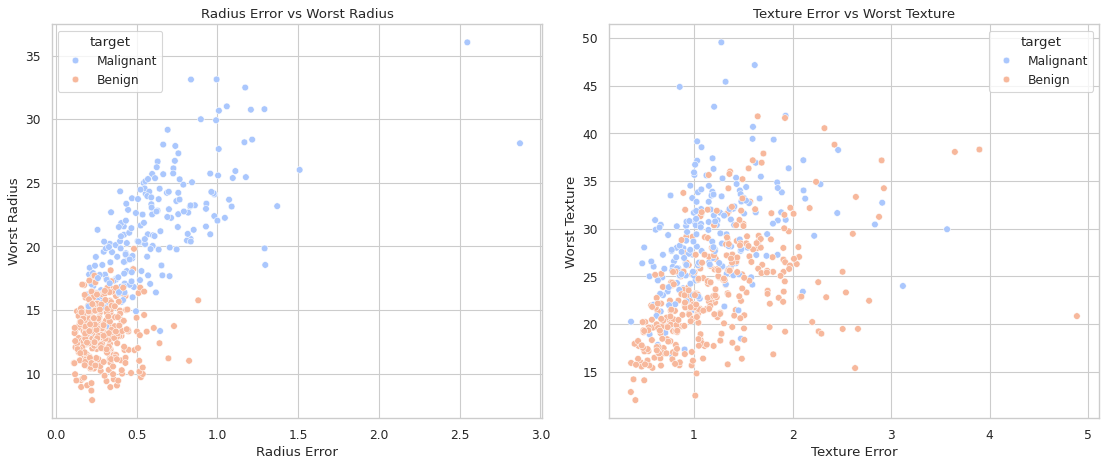

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First scatter plot
sns.scatterplot(data=full_df, x='radius error', y='worst radius', hue='target', palette='coolwarm', ax=axes[0])
axes[0].set_title("Radius Error vs Worst Radius")
axes[0].set_xlabel("Radius Error")
axes[0].set_ylabel("Worst Radius")

# Second scatter plot
sns.scatterplot(data=full_df, x='texture error', y='worst texture', hue='target', palette='coolwarm', ax=axes[1])
axes[1].set_title("Texture Error vs Worst Texture")
axes[1].set_xlabel("Texture Error")
axes[1].set_ylabel("Worst Texture")

# Adjust layout
plt.tight_layout()
plt.show()


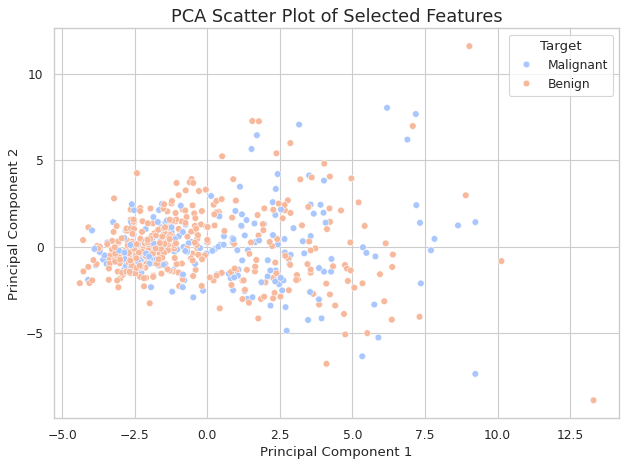

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Select the desired features
features = ['mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error',
            'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error',
            'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area',
            'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points',
            'worst symmetry', 'worst fractal dimension']

# Standardize the features
X = StandardScaler().fit_transform(full_df[features])

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['target'] = full_df['target']

# Plot the PCA result
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target', palette='coolwarm')
plt.title("PCA Scatter Plot of Selected Features", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Target')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


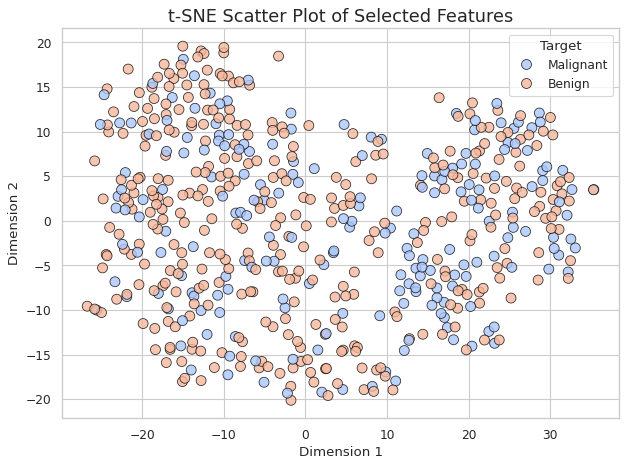

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Select the features
features = ['mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error',
            'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error',
            'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area',
            'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points',
            'worst symmetry', 'worst fractal dimension']

# Standardize the data
X_scaled = StandardScaler().fit_transform(full_df[features])

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_components = tsne.fit_transform(X_scaled)

# Prepare DataFrame for plotting
tsne_df = pd.DataFrame(data=tsne_components, columns=['Dim1', 'Dim2'])
tsne_df['target'] = full_df['target']

# Plot t-SNE
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='target', palette='coolwarm', edgecolor='black', s=80, alpha=0.8)
plt.title("t-SNE Scatter Plot of Selected Features", fontsize=16)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title='Target')
plt.tight_layout()
plt.show()


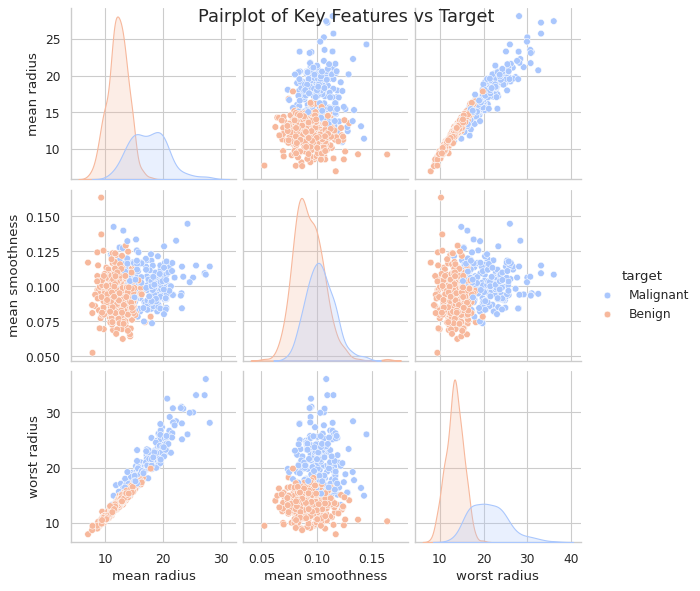

In [ ]:
sns.pairplot(full_df[['mean radius', 'mean smoothness', 'worst radius', 'target']], hue='target', palette='coolwarm')
plt.suptitle("Pairplot of Key Features vs Target", fontsize=16)
plt.show()


In [ ]:
print(full_df['target'].unique())
print(full_df['target'].dtype)


['Malignant' 'Benign']
object


#4. Classification Models

In [ ]:
df = full_df.copy()  # Create a copy of full_df and assign it to df

In [ ]:
df['target'] = df['target'].astype('category')

In [ ]:
from sklearn.model_selection import train_test_split  # Import function to split dataset into train and test sets

# Split the data into training and testing sets (features + target together)
train_set, test_set = train_test_split(
    full_df,                    # The full dataset including features and target
    test_size=0.2,              # 20% for testing
    shuffle=True,               # Shuffle before splitting
    random_state=7,             # For reproducibility
    stratify=full_df['target']  # Preserve target class distribution
)

# Separate features and target
X_train = train_set.drop(['target'], axis=1)
y_train = train_set['target'].copy()

X_test = test_set.drop(['target'], axis=1)
y_test_raw = test_set['target'].copy()


# Print shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test_raw.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test_raw.shape)


X_train shape: (451, 30)
X_test shape: (113, 30)
y_train shape: (451,)
y_test shape: (113,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Use the original raw labels
y_train_raw = train_set['target'].copy()
y_test_raw = test_set['target'].copy()

# Initialize the encoder
le = LabelEncoder()

# Fit the encoder on y_train_raw (string labels like "Benign", "Malignant")
le.fit(y_train_raw)

# Transform both y_train_raw and y_test_raw
y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)

# Preview
print("Encoded y_train:", y_train[:10])
print("Encoded y_test:", y_test[:10])


Encoded y_train: [1 0 0 0 0 0 1 1 0 1]
Encoded y_test: [1 0 0 0 0 0 0 0 1 1]


Training Accuracy: 0.9734
Test Accuracy:     0.9381

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.95      0.96      0.95        72
   Malignant       0.93      0.90      0.91        41

    accuracy                           0.94       113
   macro avg       0.94      0.93      0.93       113
weighted avg       0.94      0.94      0.94       113



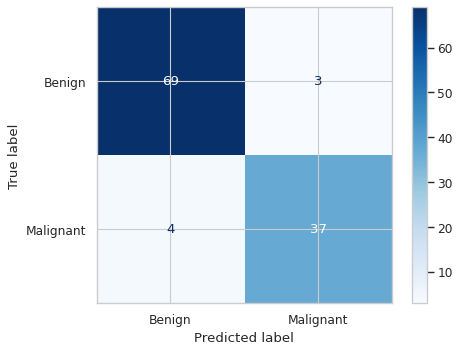

In [ ]:
#Decision_Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Step 1: Initialize and train the decision tree model with hyperparameters to reduce overfitting
tree_clf = DecisionTreeClassifier(
    max_depth=5,            # Limit tree depth to reduce overfitting
    min_samples_leaf=5,     # Ensure each leaf has at least 5 samples
    random_state=7
)
tree_clf.fit(X_train, y_train)

# Step 2: Predictions
y_train_pred = tree_clf.predict(X_train)
y_test_pred = tree_clf.predict(X_test)

# Step 3: Accuracy for both sets (Note: use y_test, not y_test_raw — they should be encoded)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

# Step 4: Confusion matrix for test set
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')

# Step 5: Classification report for test set
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))


In [ ]:
#Cross_Validation
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Step 1: Initialize the model with your chosen parameters
tree_clf = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=7)

# Step 2: Cross-validation on training data
cv_scores = cross_val_score(tree_clf, X_train, y_train_raw, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Average CV Accuracy:     {:.4f}".format(cv_scores.mean()))

# Step 3: Train the model (optional — but needed if you still want to evaluate on test set after this)
tree_clf.fit(X_train, y_train_raw)

# Step 4: Predict and evaluate as usual (test set)
y_train_pred = tree_clf.predict(X_train)
y_test_pred = tree_clf.predict(X_test)

# Step 5: Accuracy
train_acc = accuracy_score(y_train_raw, y_train_pred)
test_acc = accuracy_score(y_test_raw, y_test_pred)
print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")


Cross-Validation Scores: [0.945 0.944 0.933 0.878 0.944]
Average CV Accuracy:     0.9290

Training Accuracy: 0.9734
Test Accuracy:     0.9381


In [ ]:
import pandas as pd

# Assuming your feature names come from the training set
feature_importances = pd.Series(tree_clf.feature_importances_, index=X_train.columns)
print(feature_importances.sort_values(ascending=False))


worst concave points       0.778705
worst area                 0.160523
mean texture               0.034786
mean area                  0.007921
mean concavity             0.006571
texture error              0.004119
area error                 0.003811
smoothness error           0.002019
worst smoothness           0.001545
mean concave points        0.000000
mean compactness           0.000000
mean smoothness            0.000000
mean perimeter             0.000000
mean radius                0.000000
perimeter error            0.000000
radius error               0.000000
mean symmetry              0.000000
mean fractal dimension     0.000000
symmetry error             0.000000
compactness error          0.000000
concavity error            0.000000
concave points error       0.000000
worst texture              0.000000
worst radius               0.000000
fractal dimension error    0.000000
worst perimeter            0.000000
worst compactness          0.000000
worst concavity            0

Training Accuracy: 0.9867
Test Accuracy:     0.9381

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95        72
   Malignant       0.95      0.88      0.91        41

    accuracy                           0.94       113
   macro avg       0.94      0.93      0.93       113
weighted avg       0.94      0.94      0.94       113



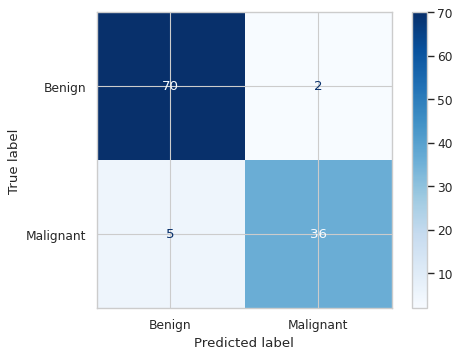

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Step 1: Initialize and train the random forest model with parameters
rf_clf = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    max_depth=8,           # Limit tree depth to reduce overfitting
    min_samples_leaf=4,    # Minimum samples required at each leaf node
    random_state=42
)
rf_clf.fit(X_train, y_train_raw)

# Step 2: Predictions
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)

# Step 3: Accuracy for both sets
train_acc = accuracy_score(y_train_raw, y_train_pred)
test_acc = accuracy_score(y_test_raw, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

# Step 4: Confusion matrix for test set
cm = confusion_matrix(y_test_raw, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')

# Step 5: Classification report for test set
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test_raw, y_test_pred, target_names=le.classes_))


Training Accuracy: 0.9623
Test Accuracy:     0.9469

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88      0.92        41

    accuracy                           0.95       113
   macro avg       0.95      0.93      0.94       113
weighted avg       0.95      0.95      0.95       113



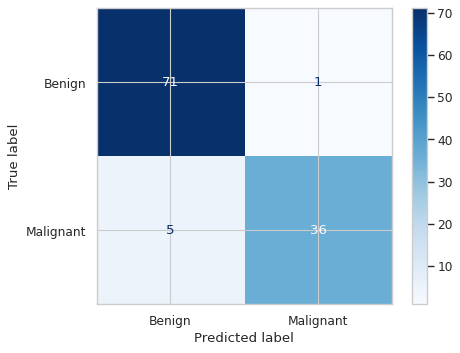

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Step 1: Initialize and train the logistic regression model
logreg_clf = LogisticRegression(
    solver='liblinear',     # Good for small to medium datasets and binary classification
    max_iter=1000,          # Increase max iterations for convergence
    random_state=42
)
logreg_clf.fit(X_train, y_train_raw)

# Step 2: Predictions
y_train_pred = logreg_clf.predict(X_train)
y_test_pred = logreg_clf.predict(X_test)

# Step 3: Accuracy for both sets
train_acc = accuracy_score(y_train_raw, y_train_pred)
test_acc = accuracy_score(y_test_raw, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

# Step 4: Confusion matrix for test set
cm = confusion_matrix(y_test_raw, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')

# Step 5: Classification report for test set
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test_raw, y_test_pred, target_names=le.classes_))


Training Accuracy: 0.9579
Test Accuracy:     0.9115

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.91      0.96      0.93        72
   Malignant       0.92      0.83      0.87        41

    accuracy                           0.91       113
   macro avg       0.91      0.89      0.90       113
weighted avg       0.91      0.91      0.91       113



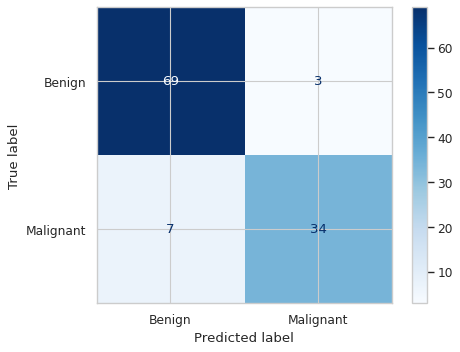

In [ ]:
#K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Step 1: Initialize and train the KNN model
knn_clf = KNeighborsClassifier(
    n_neighbors=5,   # Number of neighbors to use
    weights='uniform'  # All points in each neighborhood are weighted equally
)
knn_clf.fit(X_train, y_train_raw)

# Step 2: Predictions
y_train_pred = knn_clf.predict(X_train)
y_test_pred = knn_clf.predict(X_test)

# Step 3: Accuracy for both sets
train_acc = accuracy_score(y_train_raw, y_train_pred)
test_acc = accuracy_score(y_test_raw, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

# Step 4: Confusion matrix for test set
cm = confusion_matrix(y_test_raw, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')

# Step 5: Classification report for test set
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test_raw, y_test_pred, target_names=le.classes_))


Training Accuracy: 0.9534
Test Accuracy:     0.9027

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.89      0.97      0.93        72
   Malignant       0.94      0.78      0.85        41

    accuracy                           0.90       113
   macro avg       0.91      0.88      0.89       113
weighted avg       0.91      0.90      0.90       113



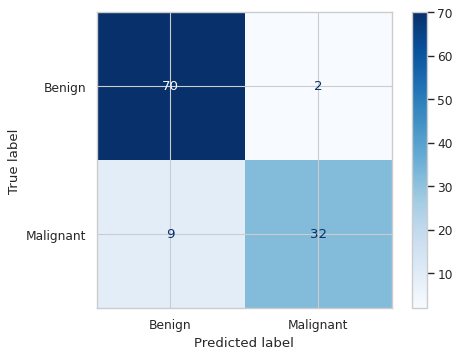

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Step 1: Initialize and train the Naive Bayes model
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train_raw)

# Step 2: Predictions
y_train_pred = nb_clf.predict(X_train)
y_test_pred = nb_clf.predict(X_test)

# Step 3: Accuracy for both sets
train_acc = accuracy_score(y_train_raw, y_train_pred)
test_acc = accuracy_score(y_test_raw, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

# Step 4: Confusion matrix for test set
cm = confusion_matrix(y_test_raw, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')

# Step 5: Classification report for test set
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test_raw, y_test_pred, target_names=le.classes_))


# 5. Model Comparison

In [ ]:
import pandas as pd

# Define the model performance data
model_comparison = {
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression", "KNN", "Naive Bayes"],
    "Train Acc": [0.9734, 0.9867, 0.9623, 0.9579, 0.9534],
    "Test Acc": [0.9381, 0.9381, 0.9469, 0.9115, 0.9027],
    "Precision (Benign)": [0.95, 0.93, 0.93, 0.91, 0.89],
    "Recall (Benign)": [0.96, 0.97, 0.99, 0.96, 0.97],
    "Precision (Malignant)": [0.93, 0.95, 0.97, 0.92, 0.94],
    "Recall (Malignant)": [0.90, 0.88, 0.88, 0.83, 0.78],
    "Weighted F1": [0.94, 0.94, 0.95, 0.91, 0.90]
}

# Create the DataFrame
df_comparison = pd.DataFrame(model_comparison)

# Display the DataFrame
df_comparison


,Model,Train Acc,Test Acc,Precision (Benign),Recall (Benign),Precision (Malignant),Recall (Malignant),Weighted F1
0,Decision Tree,0.9734,0.9381,0.95,0.96,0.93,0.90,0.94
1,Random Forest,0.9867,0.9381,0.93,0.97,0.95,0.88,0.94
2,Logistic Regression,0.9623,0.9469,0.93,0.99,0.97,0.88,0.95
3,KNN,0.9579,0.9115,0.91,0.96,0.92,0.83,0.91
4,Naive Bayes,0.9534,0.9027,0.89,0.97,0.94,0.78,0.90


ROC AUC Scores by Model:
------------------------------
Decision Tree       : 0.94
Random Forest       : 0.99
Naive Bayes         : 0.98
Logistic Regression : 0.99
KNN                 : 0.96


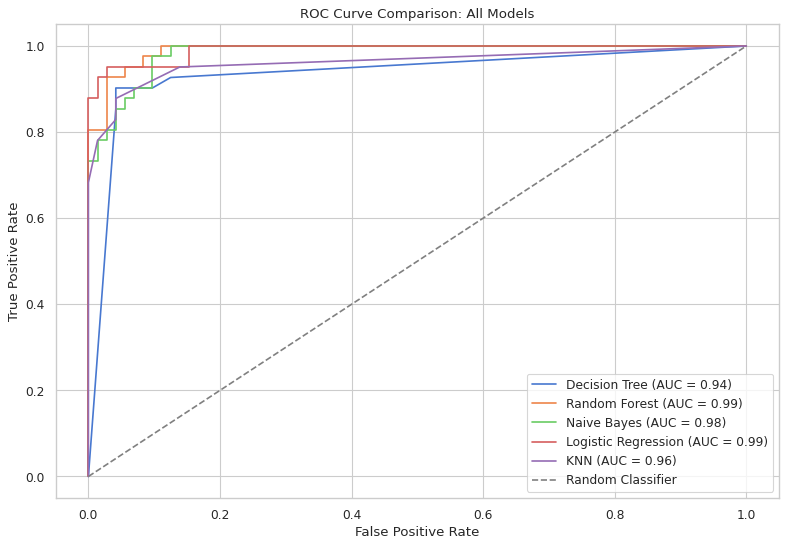

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Encode the labels to binary (0 = Benign, 1 = Malignant) for ROC only
y_test_binary = le.transform(y_test_raw)

# Step 2: Get predicted probabilities for the positive class (Malignant)
dt_probs = tree_clf.predict_proba(X_test)[:, 1]
rf_probs = rf_clf.predict_proba(X_test)[:, 1]
nb_probs = nb_clf.predict_proba(X_test)[:, 1]
lr_probs = logreg_clf.predict_proba(X_test)[:, 1]
knn_probs = knn_clf.predict_proba(X_test)[:, 1]

# Step 3: Define function to compute ROC and AUC
def compute_roc_auc(y_true, y_probs):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    return fpr, tpr, auc(fpr, tpr)

# Step 4: Compute ROC data for each model
dt_fpr, dt_tpr, dt_auc = compute_roc_auc(y_test_binary, dt_probs)
rf_fpr, rf_tpr, rf_auc = compute_roc_auc(y_test_binary, rf_probs)
nb_fpr, nb_tpr, nb_auc = compute_roc_auc(y_test_binary, nb_probs)
lr_fpr, lr_tpr, lr_auc = compute_roc_auc(y_test_binary, lr_probs)
knn_fpr, knn_tpr, knn_auc = compute_roc_auc(y_test_binary, knn_probs)

# Step 5: Function to print ROC AUC results
def print_roc_auc_results():
    print("ROC AUC Scores by Model:")
    print("-" * 30)
    print(f"Decision Tree       : {dt_auc:.2f}")
    print(f"Random Forest       : {rf_auc:.2f}")
    print(f"Naive Bayes         : {nb_auc:.2f}")
    print(f"Logistic Regression : {lr_auc:.2f}")
    print(f"KNN                 : {knn_auc:.2f}")

# Now call the print function AFTER it's defined
print_roc_auc_results()

# Step 6: Plot all ROC curves
plt.figure(figsize=(10, 7))
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC = {nb_auc:.2f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

# Formatting
plt.title('ROC Curve Comparison: All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# 6. Conclusion

Logistic Regression is the best models.


Highest ROC AUC (0.99) — excellent at distinguishing between benign and malignant.

Highest Test Accuracy (0.9469) — generalizes well on new data.

Highest Weighted F1 (0.95) — balanced performance on both classes.

It provides a strong mix of:

- Simplicity & interpretability

- Strong classification power

- Low risk of overfitting

Runner-up: Random Forest
prioritize robustness and handling complex data structures (e.g., many features or interactions), Random Forest is also a very strong candidate.

